# Figure 3 — Marker expression across timepoints and condition

Plots:

- **a**: Stacked violin plot of selected fibroblast markers across D1/D2/D4 × CTRL/EXP groups

Reads `sub_fibroblasts.h5ad` (all fibroblasts pooled) from the preprocessing notebook's final save.

**Display renames** (matching the manuscript axis labels):
- `obs['timepoint']`: `Day1`/`Day2`/`Day4` → `D1`/`D2`/`D4`
- `obs['condition']`: `Control`/`Expanded` → `CTRL`/`EXP`

The renames live in new `obs` columns; the underlying annotations stay untouched.

## Imports

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Output directory for the saved figure SVGs
out_dir = Path('../manuscript_figures/figure_3')
out_dir.mkdir(parents=True, exist_ok=True)

sc.settings.set_figure_params(dpi=80, facecolor='white', frameon=False)

## Load processed data

In [2]:
sub_fibro = sc.read_h5ad('../../results/sub_fibroblasts.h5ad')

print(f'sub_fibro: {sub_fibro.n_obs} cells, {sub_fibro.n_vars} genes')
print('\ntimepoint counts:')
print(sub_fibro.obs['timepoint'].value_counts())
print('\ncondition counts:')
print(sub_fibro.obs['condition'].value_counts())

sub_fibro: 15419 cells, 32285 genes

timepoint counts:
timepoint
Day1    8286
Day2    3761
Day4    3372
Name: count, dtype: int64

condition counts:
condition
Control     11634
Expanded     3785
Name: count, dtype: int64


## Build composite group label (timepoint × condition)

Panel a groups cells by timepoint × condition. We rename `Day1/Day2/Day4` to `D1/D2/D4`
and `Control/Expanded` to `CTRL/EXP` for display, then build a single `obs` column
`timepoint_condition` ordered left-to-right as in the figure: D1 CTRL, D1 EXP, D2 CTRL,
D2 EXP, D4 CTRL, D4 EXP.

In [3]:
# Display renames
timepoint_short = {
    'Day1': 'D1',
    'Day2': 'D2',
    'Day4': 'D4',
}
condition_short = {
    'Control':  'CTRL',
    'Expanded': 'EXP',
}

sub_fibro.obs['timepoint_short'] = (
    sub_fibro.obs['timepoint'].astype(str).replace(timepoint_short)
)
sub_fibro.obs['condition_short'] = (
    sub_fibro.obs['condition'].astype(str).replace(condition_short)
)
sub_fibro.obs['timepoint_condition'] = (
    sub_fibro.obs['timepoint_short'].astype(str)
    + ' '
    + sub_fibro.obs['condition_short'].astype(str)
)

# Order: D1 CTRL, D1 EXP, D2 CTRL, D2 EXP, D4 CTRL, D4 EXP
group_order = [
    'D1 CTRL', 'D1 EXP',
    'D2 CTRL', 'D2 EXP',
    'D4 CTRL', 'D4 EXP',
]

# Sanity checks
present = set(sub_fibro.obs['timepoint_condition'].unique())
missing_groups = [g for g in group_order if g not in present]
if missing_groups:
    print(f'WARNING: {len(missing_groups)} group(s) missing from data: {missing_groups}')
extra_groups = sorted(present - set(group_order))
if extra_groups:
    print(f'NOTE: {len(extra_groups)} group(s) present in data but not in figure order: {extra_groups}')

sub_fibro.obs['timepoint_condition'] = pd.Categorical(
    sub_fibro.obs['timepoint_condition'], categories=group_order, ordered=True,
)

print('\ntimepoint_condition counts:')
print(sub_fibro.obs['timepoint_condition'].value_counts().reindex(group_order))


timepoint_condition counts:
timepoint_condition
D1 CTRL    6230
D1 EXP     2056
D2 CTRL    2725
D2 EXP     1036
D4 CTRL    2679
D4 EXP      693
Name: count, dtype: int64


## Panel a — Stacked violin of fibroblast markers across timepoint × condition

Genes (y-axis, top → bottom in figure): *Pdpn, Tnc, Timp1, Mmp13, Crabp1, Pdgfra, Cd34*.
Colour = median expression in group (viridis). Uses log-normalized counts.

Scanpy's default `colorbar_title` for `stacked_violin` is already `'Median expression\nin group'`,
so we don't override it.

In [4]:
# Marker gene list (transcribed from the figure y-axis, top -> bottom)
panel_a_genes = [
    'Pdpn', 'Tnc', 'Timp1', 'Mmp13', 'Crabp1', 'Pdgfra', 'Cd34',
]

missing = [g for g in panel_a_genes if g not in sub_fibro.var_names]
if missing:
    print(f'WARNING: {len(missing)} marker gene(s) not found in sub_fibro: {missing}')
genes_present = [g for g in panel_a_genes if g in sub_fibro.var_names]
print(f'{len(genes_present)} / {len(panel_a_genes)} genes present')

7 / 7 genes present


/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  row_ax = sns.violinplot(
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  row_ax = sns.violinplot(
/mnt/

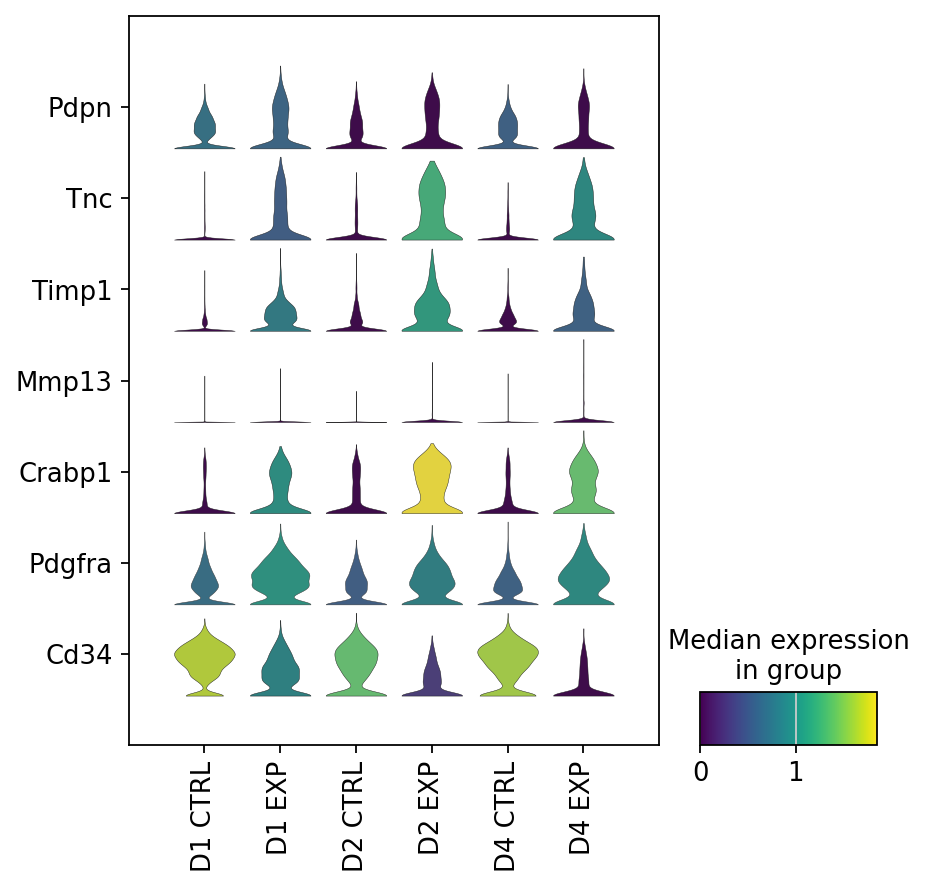

In [12]:
# Use log-normalized counts for visualization (not z-scored)
sub_fibro.X = sub_fibro.layers['logcounts']

sv = sc.pl.stacked_violin(
    sub_fibro,
    var_names=genes_present,
    groupby='timepoint_condition',
    categories_order=group_order,
    cmap='viridis',
    swap_axes=True,         # genes on y-axis, groups on x-axis (matches figure)
    figsize=(6, 6),
    return_fig=True,
    show=False,
)

sv = sv.style(
    cmap='viridis',         # repeat cmap (same gotcha as dotplot in fig 1f)
)

sv.savefig(out_dir / 'fig3a_stacked_violin_markers.svg',
           dpi=300, bbox_inches='tight')
plt.show()